# Analysis of coexpressed gene pairs
## Setup for tissue specific GO
### Author: Martin Loza
### Date: 26/01/19


In [40]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "260119"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
gray = "gray50"
text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

go_results_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/09_Figure_Correlation_ENCODE_GTEx/Results/"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/09_Figure_Correlation_ENCODE_GTEx/Plots/"
supplementary_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
# Local Functions



### Load and setup the data

In [41]:
sel_tissues <- c('Testis','Brain_Cerebellum',
                'Skin_Not_Sun_Exposed_Suprapubic','Pancreas_Islets',
                'Cells_Cultured_fibroblasts','Cervix_Endocervix','Vagina')

# Load the GO results of selected tissues
go_results <- list()

for(tissue in sel_tissues) {
    go_df <- read.csv2(paste0(go_results_dir, tissue, "_260119.csv"),sep = ",")
    go_df$Tissue <- tissue
    # Set Fold.Enrichment and FDR to numeric
    go_df$Fold.Enrichment <- as.numeric(go_df$Fold.Enrichment)
    go_df$FDR <- as.numeric(go_df$FDR)
    go_results[[tissue]] <- go_df
}

# Merge the go_results
go_results <- Reduce(rbind, go_results)

head(go_results,2)

,Category,Term,Genes,Count,List.Total,Pop.Hits,Pop.Total,P.Value,Benjamini,Fold.Enrichment,Bonferroni,FDR,Fisher.Exact,Tissue
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,GOTERM_BP_DIRECT,regulation of DNA-templated transcription,90.00%,9,10,1526,19512,1.15e-8,1.25e-6,11.51,1.39e-6,1.24e-06,9.96e-10,Testis
2,GOTERM_BP_DIRECT,regulation of transcription by RNA polymerase II,90.00%,9,10,1643,19512,2.07e-8,1.25e-6,10.69,2.51e-6,1.24e-06,1.93e-9,Testis


In [42]:
# Save supplementary table
write.table(go_results, file = paste0(supplementary_dir, "Supplementary_Tissue_specific_GO_results_", date, ".tsv"), sep = "\t", row.names = FALSE)

In [43]:
# There were some Terms repeated across tissues, let's check them
term_counts <-go_results %>%
        group_by(Term) %>%
        summarise(n_tissues = n()) %>%
        arrange(desc(n_tissues))
head(term_counts,4)

Term,n_tissues
<chr>,<int>
positive regulation of transcription by RNA polymerase II,7
regulation of DNA-templated transcription,7
regulation of transcription by RNA polymerase II,7
anatomical structure morphogenesis,6


Let's remove those related to more than 3 tissues (around 50%)

In [44]:
terms_remove = term_counts %>% filter(n_tissues >=3) %>% pull(Term)
terms_remove

[1] "positive regulation of transcription by RNA polymerase II"
 [2] "regulation of DNA-templated transcription"                
 [3] "regulation of transcription by RNA polymerase II"         
 [4] "anatomical structure morphogenesis"                       
 [5] "anterior/posterior pattern specification"                 
 [6] "cell differentiation"                                     
 [7] "neuron differentiation"                                   
 [8] "positive regulation of DNA-templated transcription"       
 [9] "skeletal system development"                              
[10] "transcription by RNA polymerase II"

In [45]:
# remove Terms from more than 3 tissues
sel_go_results <- go_results %>% filter(!Term %in% terms_remove)
sel_go_results %>% 
    group_by(Tissue) %>%
    summarise(n_terms = n())

Tissue,n_terms
<chr>,<int>
Brain_Cerebellum,27
Cells_Cultured_fibroblasts,1
Cervix_Endocervix,10
Pancreas_Islets,23
Skin_Not_Sun_Exposed_Suprapubic,3
Testis,5


In [46]:
# Let's select the top 5 terms per tissue using the Fold.Enrichment and FDR values
top_go_results <- sel_go_results %>%
    group_by(Tissue) %>%
    arrange(FDR, desc(Fold.Enrichment)) %>%
    slice_head(n = 5) %>%
    ungroup()

head(top_go_results %>% select(Term,Tissue),10)

Term,Tissue
<chr>,<chr>
nervous system development,Brain_Cerebellum
forebrain development,Brain_Cerebellum
primitive streak formation,Brain_Cerebellum
neuron fate commitment,Brain_Cerebellum
cerebellar Purkinje cell-granule cell precursor cell signaling,Brain_Cerebellum
proximal/distal pattern formation,Cells_Cultured_fibroblasts
prostate gland development,Cervix_Endocervix
male genitalia development,Cervix_Endocervix
uterus development,Cervix_Endocervix


### Prepare data for plotting

In [49]:
# Prepare plotting data - similar to 04_GO_plots.ipynb
plot_data <- top_go_results %>%
    mutate(
        neg_log_FDR = -log10(FDR)
    ) %>%
    # Order terms by FDR within each tissue for proper plotting
    group_by(Tissue) %>%
    arrange(neg_log_FDR) %>%
    mutate(Term_order = row_number()) %>%
    ungroup()

# Get the range of Count values for shared scale
count_range <- range(plot_data$Count, na.rm = TRUE)

head(plot_data %>% select(Tissue, neg_log_FDR, Count), 10)

Tissue,neg_log_FDR,Count
<chr>,<dbl>,<int>
Testis,0.1129456,2
Skin_Not_Sun_Exposed_Suprapubic,0.1260984,2
Testis,0.2168113,2
Testis,0.2211255,2
Testis,0.2881928,2
Skin_Not_Sun_Exposed_Suprapubic,0.3344190,2
Testis,0.5316527,4
Skin_Not_Sun_Exposed_Suprapubic,0.5833595,3
Cells_Cultured_fibroblasts,1.0141246,2


### GO Enrichment Plot - Tissue Specific

Lollipop plots showing GO enrichment results with -log10(FDR) and gene count for each tissue.

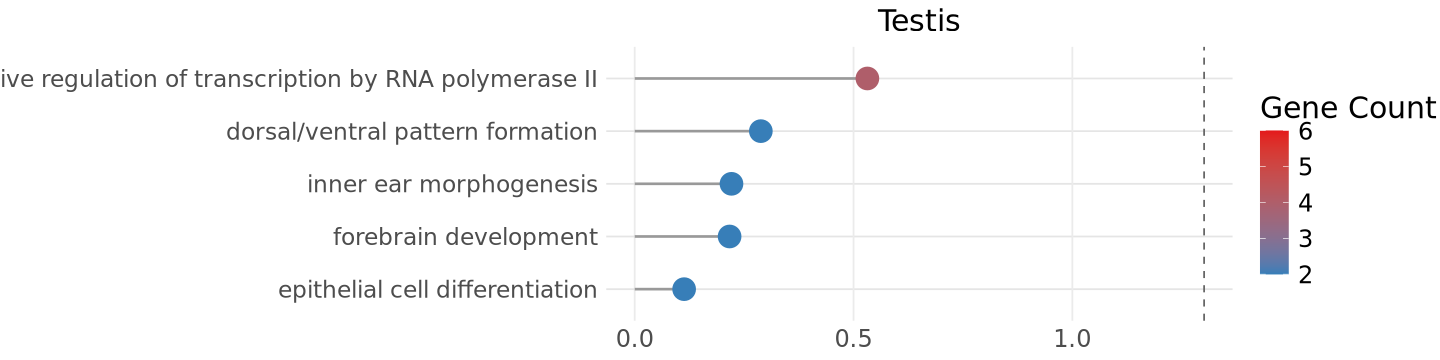

In [76]:
# Create individual plots for each tissue
tissue_plots <- list()

for(tissue in unique(plot_data$Tissue)) {
    # Filter and prepare data for this tissue
    tissue_data <- plot_data %>%
        filter(Tissue == tissue) %>%
        arrange(neg_log_FDR) %>%
        mutate(Term = factor(Term, levels = unique(Term)))
    
    # Create lollipop plot
    p <- tissue_data %>%
        ggplot(aes(x = neg_log_FDR, y = Term)) +
        geom_segment(aes(x = 0, xend = neg_log_FDR, y = Term, yend = Term),
                     color = "gray60", linewidth = line_size * 0.5) +
        geom_point(aes(color = Count), size = dot_size * 1.5) +
        geom_vline(xintercept = -log10(0.05), linetype = "dashed", color = "gray40") +
        scale_color_gradient(low = blue, high = red, name = "Gene Count", limits = count_range) +
        theme_minimal() +
        labs(x = NULL, y = NULL, title = unique(tissue_data$Tissue)) +
        theme(
            text = element_text(size = text_size),
            axis.text.y = element_text(size = text_size - 4),
            plot.title = element_text(size = text_size, hjust = 0.5),
            legend.position = "right",
            panel.grid.major.y = element_line(color = "gray90"),
            panel.grid.minor = element_blank()
        )
    
    tissue_plots[[tissue]] <- p
}

# Display the first plot as a preview
options(repr.plot.width=12, repr.plot.height=3)
tissue_plots[[1]]

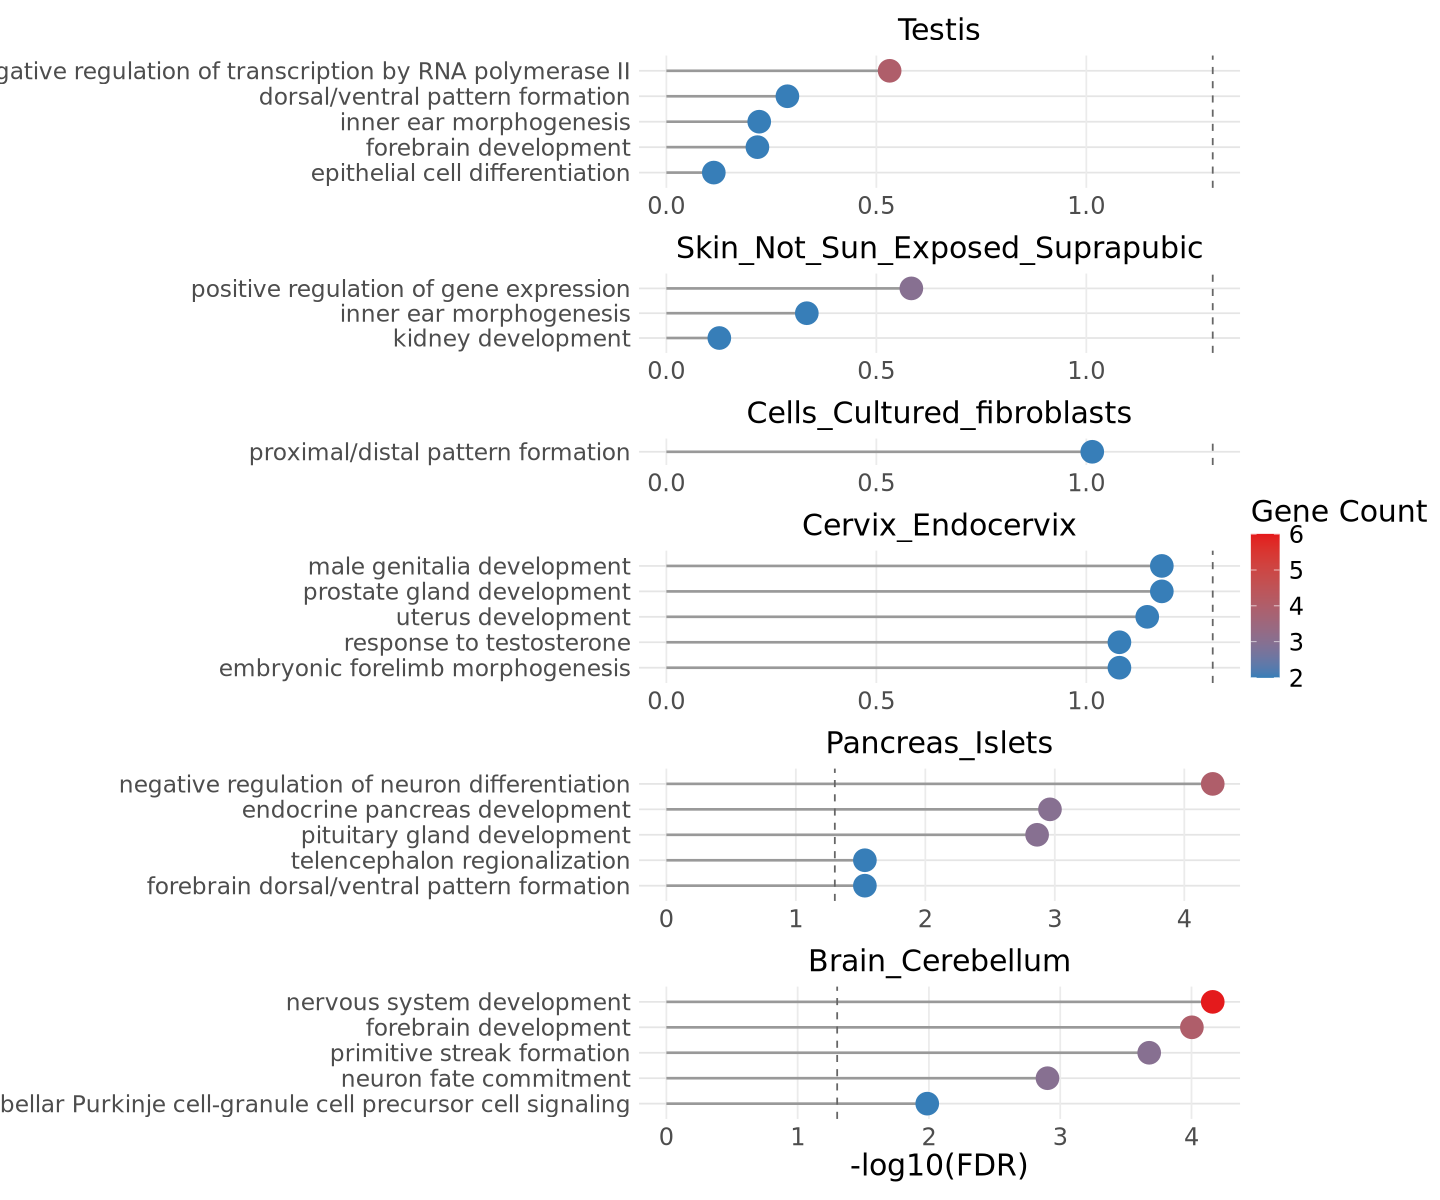

In [83]:
# Combine all tissue plots using patchwork
# Stack plots vertically with shared legend

# Update the last plot to have x-axis label
tissue_plots[[6]] <- tissue_plots[[6]] + 
    labs(x = "-log10(FDR)")

# Recreate combined plot with x-axis label and adjusted legend
p_combined <- tissue_plots[[1]] + 
    tissue_plots[[2]] + 
    tissue_plots[[3]] + 
    tissue_plots[[4]] + 
    tissue_plots[[5]] + 
    tissue_plots[[6]] + 
    plot_layout(ncol = 1, heights = c(1,0.6,.2,1,1,1), guides = "collect") +
    plot_annotation(theme = theme(
        plot.title = element_text(size = text_size + 2),
        legend.margin = margin(0, 0, 0, 0),
        legend.box.margin = margin(0, 0, 0, -10)
    ))

options(repr.plot.width=12, repr.plot.height=10)
p_combined

In [84]:
-log10(0.05)

[1] 1.30103

### Save the plot

In [85]:
# Save the tissue-specific GO enrichment plot
ggsave(filename = file.path(out_dir, paste0("Tissue_specific_GO_enrichment_", date, ".pdf")),
    plot = p_combined, 
    width = width * 0.6, height = 10, units = "in", dpi = dpi)

print(paste("Plot saved to:", file.path(out_dir, paste0("Tissue_specific_GO_enrichment_", date, ".pdf"))))

[1] "Plot saved to: /mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/09_Figure_Correlation_ENCODE_GTEx/Plots//Tissue_specific_GO_enrichment_260119.pdf"
